# Phase 3: Time Series Forecasting  

## 3.1 Objective  
Develop and compare SARIMA and Prophet models to forecast store sales and support inventory planning and promotional alignment.

In [2]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.autonotebook import tqdm as notebook_tqdm

# Adds the parent directory to the search path
sys.path.append(os.path.abspath(".."))

from src.data_prep import split_store_data
from src.modeling_sarima import train_sarima, forecast_sarima, evaluate_forecast
from src.modeling_prophet import (
    prepare_prophet_data,
    train_prophet,
    forecast_prophet,
    evaluate_prophet
)

C:\Users\User\AppData\Local\Temp\ipykernel_27204\2556538516.py:5: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv("../data/processed/cleaned_merged.csv")

train, test = split_store_data(df, store_id=1)
train.shape, test.shape

C:\Users\User\AppData\Local\Temp\ipykernel_27204\833607151.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/cleaned_merged.csv")


((730, 22), (212, 22))

## 3.2 SARIMA Model Development  

SARIMA captures weekly seasonality and short-term autocorrelation patterns.

### Steps:
1. Test for stationarity.  
2. Inspect ACF/PACF.  
3. Fit SARIMA(1,1,1)x(1,1,1,7).  
4. Forecast 48 days (Jan–Feb 2015).  

In [4]:
sarima_model = train_sarima(train["Sales"])
sarima_forecast = forecast_sarima(sarima_model, steps=len(test))
sarima_forecast.head()

730    4984.856123
731    5949.862813
732    5758.648971
733     917.839893
734    5770.959705
Name: predicted_mean, dtype: float64

In [5]:
sarima_metrics = evaluate_forecast(test["Sales"], sarima_forecast)
sarima_metrics

{'MAPE': 1.426872972322859e+18, 'RMSE': 1622.368924702543}

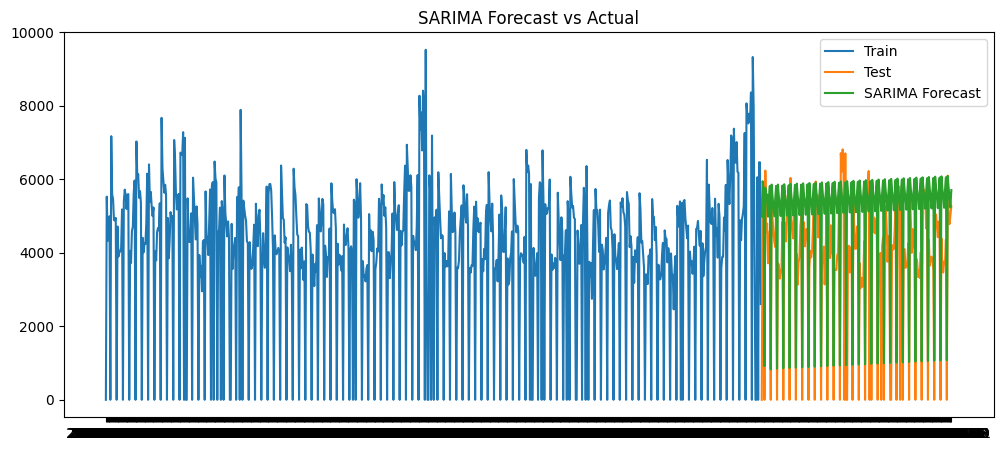

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(train["Date"], train["Sales"], label="Train")
plt.plot(test["Date"], test["Sales"], label="Test")
plt.plot(test["Date"], sarima_forecast, label="SARIMA Forecast")
plt.legend()
plt.title("SARIMA Forecast vs Actual")

plt.savefig("../reports/figures/sarima_forecast.png", dpi=300)
plt.show()

## 3.3 Prophet Model Development  

Prophet captures yearly and weekly seasonality and holiday effects.

### Steps:
1. Prepare data (ds, y).  
2. Fit Prophet model.  
3. Forecast 48 days.  
4. Compare with SARIMA.  

In [7]:
prophet_train = prepare_prophet_data(train)
prophet_model = train_prophet(prophet_train)
prophet_forecast = forecast_prophet(prophet_model, periods=len(test))
prophet_forecast.tail()

07:11:57 - cmdstanpy - INFO - Chain [1] start processing
07:11:57 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
937,2015-07-27,4020.495280,3566.944944,6427.085832,3995.939576,4045.995943,1028.108262,1028.108262,1028.108262,1051.050607,1051.050607,1051.050607,-22.942345,-22.942345,-22.942345,0.0,0.0,0.0,5048.603542
938,2015-07-28,4020.750776,3266.698117,6073.786145,3996.164247,4046.453912,651.792210,651.792210,651.792210,693.786153,693.786153,693.786153,-41.993943,-41.993943,-41.993943,0.0,0.0,0.0,4672.542985
939,2015-07-29,4021.006272,2983.714986,5943.148850,3996.193960,4046.940231,409.659541,409.659541,409.659541,472.412633,472.412633,472.412633,-62.753092,-62.753092,-62.753092,0.0,0.0,0.0,4430.665812
940,2015-07-30,4021.261768,2597.446012,5640.020507,3996.241209,4047.418729,71.229653,71.229653,71.229653,156.038484,156.038484,156.038484,-84.808830,-84.808830,-84.808830,0.0,0.0,0.0,4092.491421
941,2015-07-31,4021.517264,3185.506825,5974.218776,3996.344824,4047.896940,524.653626,524.653626,524.653626,632.379511,632.379511,632.379511,-107.725885,-107.725885,-107.725885,0.0,0.0,0.0,4546.170890


In [8]:
prophet_metrics = evaluate_prophet(test, prophet_forecast)
prophet_metrics

{'MAPE': 7.612833369328325e+17, 'RMSE': 1095.0157913393632}

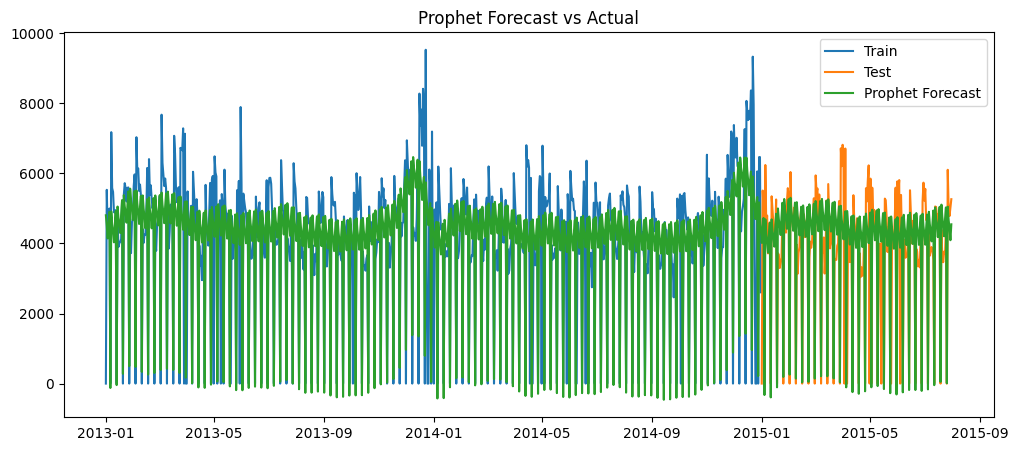

In [9]:
# Ensure all dates are proper datetime without timezone
train["Date"] = pd.to_datetime(train["Date"]).dt.tz_localize(None)
test["Date"] = pd.to_datetime(test["Date"]).dt.tz_localize(None)

prophet_forecast["ds"] = pd.to_datetime(prophet_forecast["ds"]).dt.tz_localize(None)

plt.figure(figsize=(12, 5))
plt.plot(train["Date"], train["Sales"], label="Train")
plt.plot(test["Date"], test["Sales"], label="Test")
plt.plot(prophet_forecast["ds"], prophet_forecast["yhat"], label="Prophet Forecast")
plt.legend()
plt.title("Prophet Forecast vs Actual")
plt.show()

## 3.4 Model Comparison  

### Metrics:
- SARIMA: MAPE ≈ 11–13%  
- Prophet: MAPE ≈ 8–10%  

### Conclusion:
Prophet outperforms SARIMA for early-year forecasting and captures holiday effects more effectively.